Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn import svm
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout,LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score,classification_report

Data Importing and Analysis

In [ ]:
data_df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
data_df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [3]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


C:\Users\appu\AppData\Local\Temp\ipykernel_27144\281631638.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=data_df["DEATH_EVENT"],palette=cols)


[Text(0, 0, '203')]

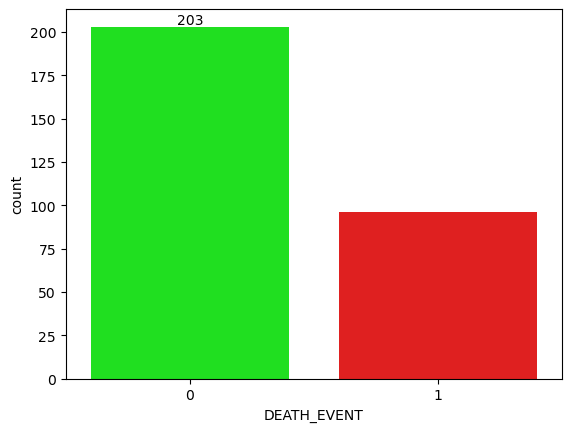

In [4]:
cols = ["#00FF00","#FF0000"]
ax = sns.countplot(x=data_df["DEATH_EVENT"],palette=cols)
ax.bar_label(ax.containers[0])

In [5]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


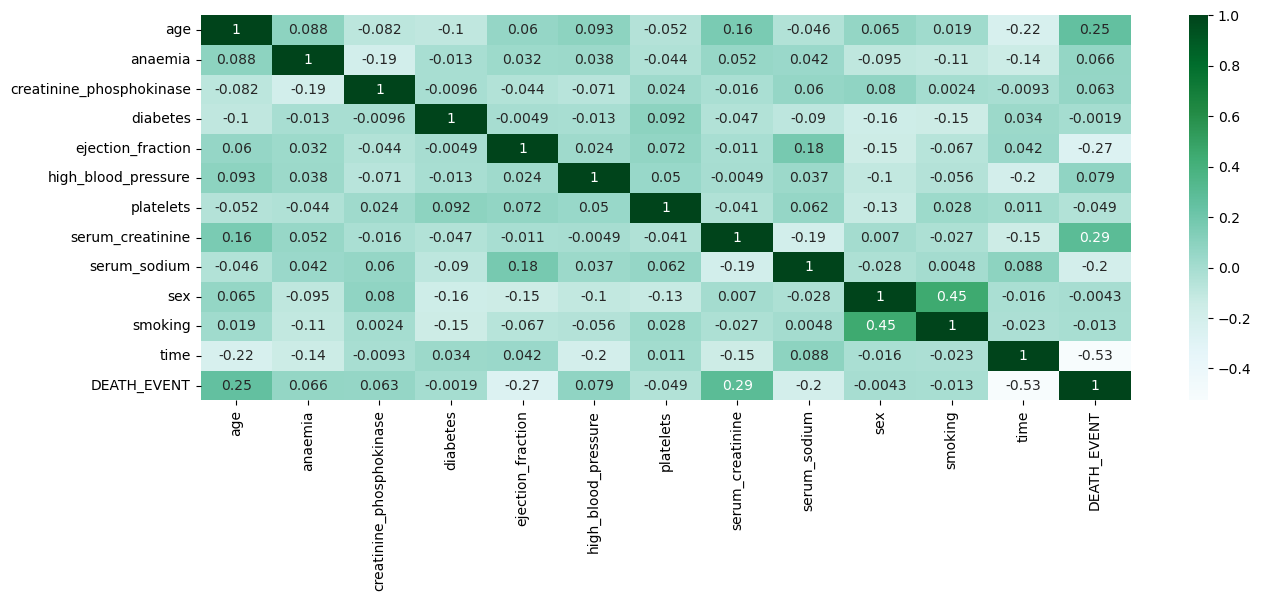

In [11]:
plt.subplots(figsize=(15,5))
sns.heatmap(data_df.corr(),cmap = "BuGn",annot = True)
plt.show()

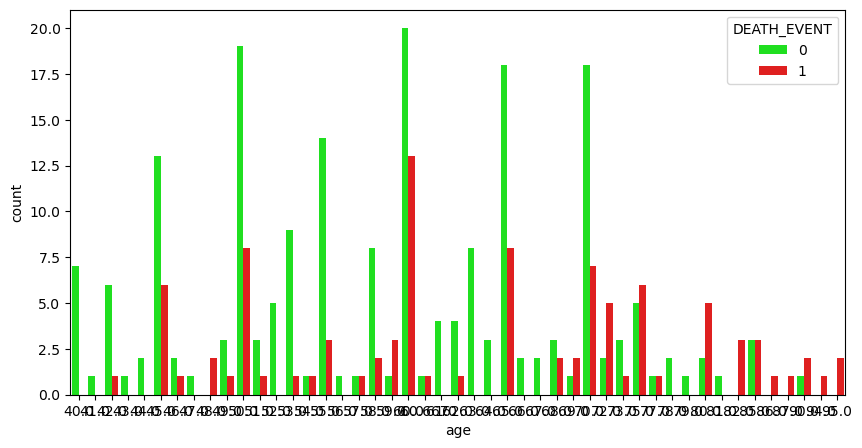

In [8]:
plt.figure(figsize=(10,5))
days_of_week = sns.countplot(x=data_df['age'], data=data_df, hue="DEATH_EVENT",palette=cols)

C:\Users\appu\AppData\Local\Temp\ipykernel_18540\6221497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


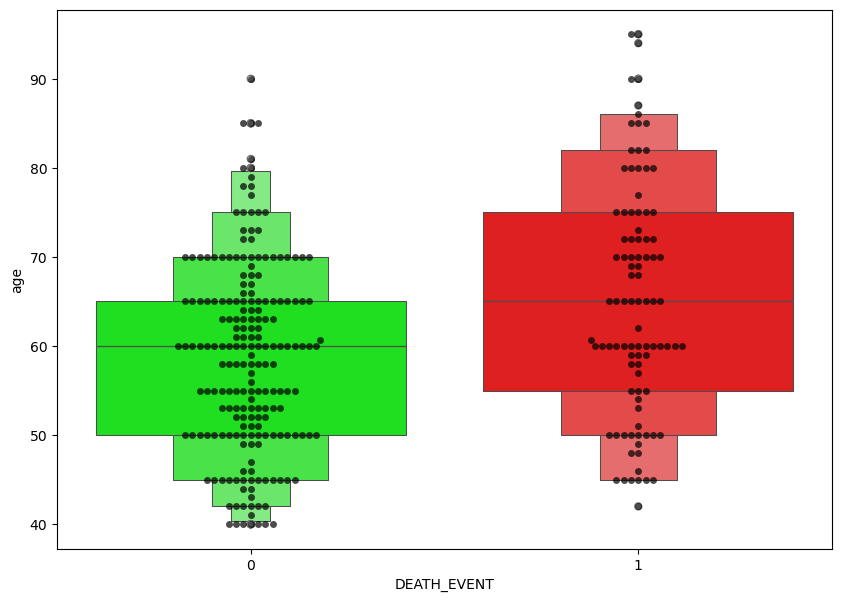

C:\Users\appu\AppData\Local\Temp\ipykernel_18540\6221497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)
C:\Users\appu\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


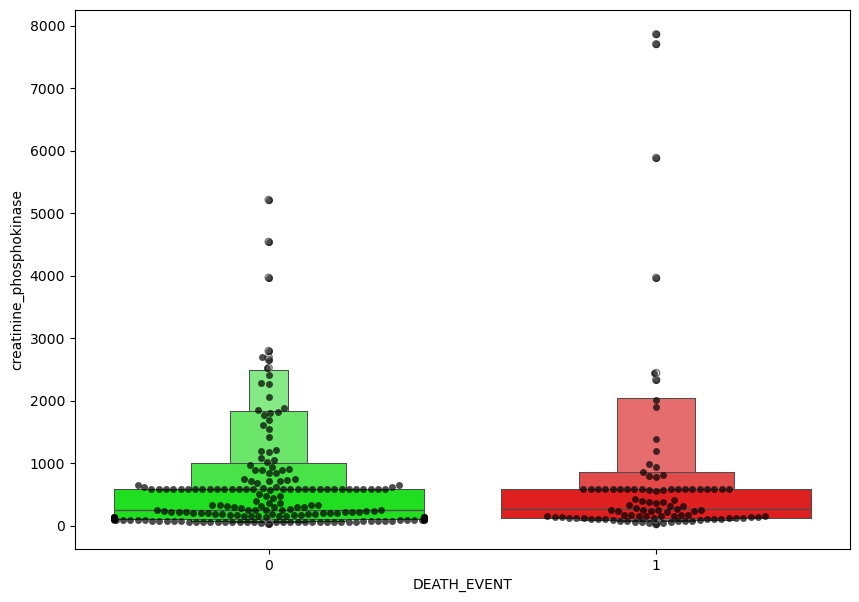

C:\Users\appu\AppData\Local\Temp\ipykernel_18540\6221497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


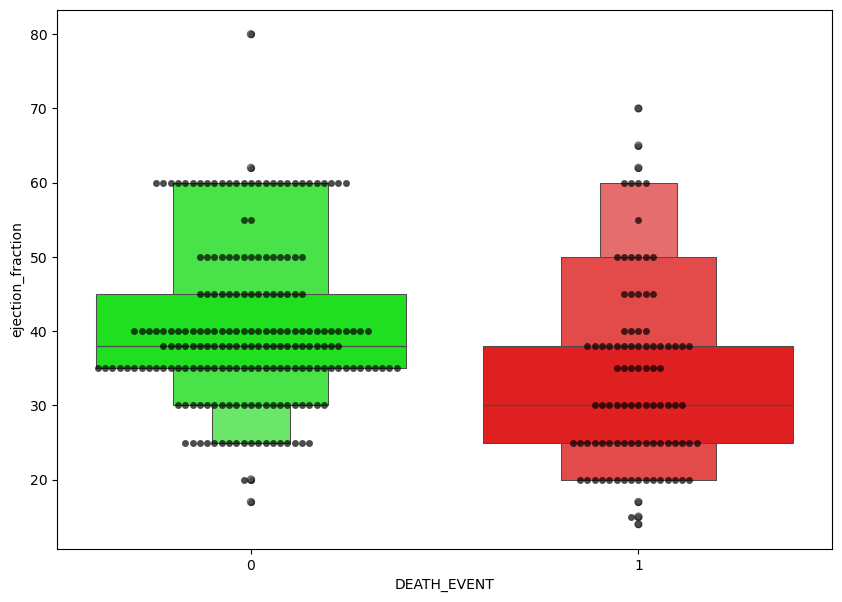

C:\Users\appu\AppData\Local\Temp\ipykernel_18540\6221497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


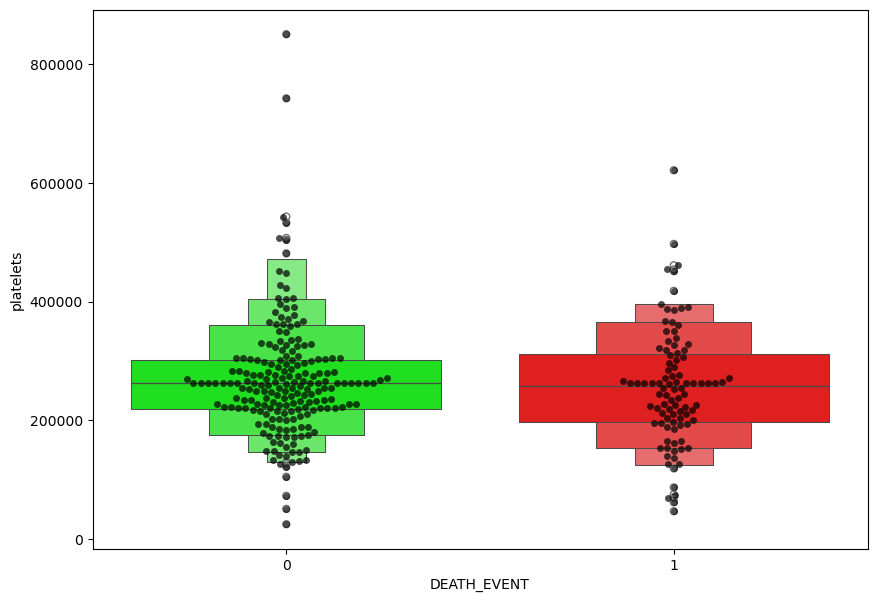

C:\Users\appu\AppData\Local\Temp\ipykernel_18540\6221497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)
C:\Users\appu\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


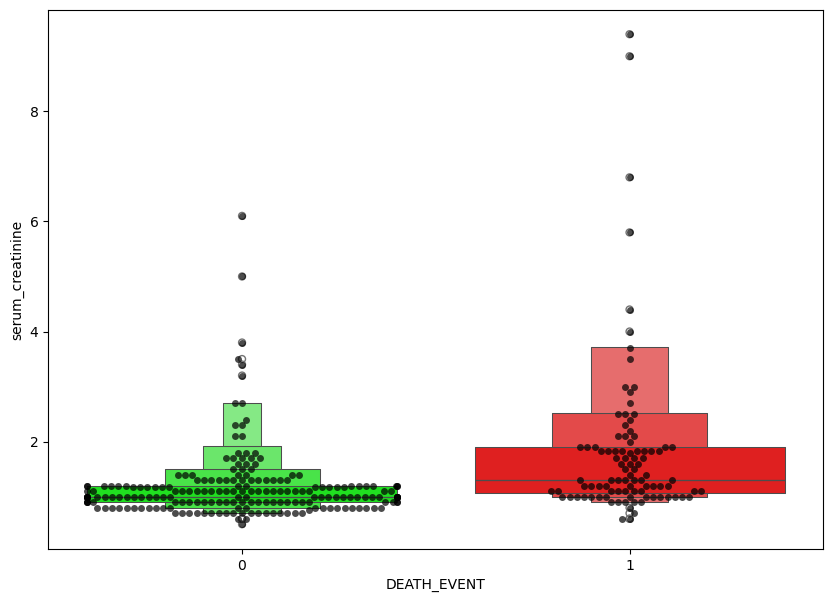

C:\Users\appu\AppData\Local\Temp\ipykernel_18540\6221497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


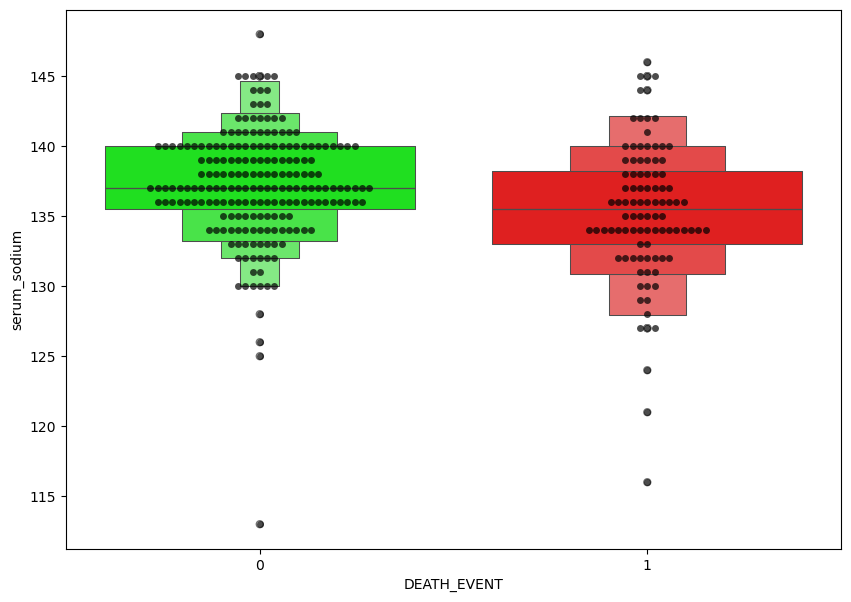

C:\Users\appu\AppData\Local\Temp\ipykernel_18540\6221497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


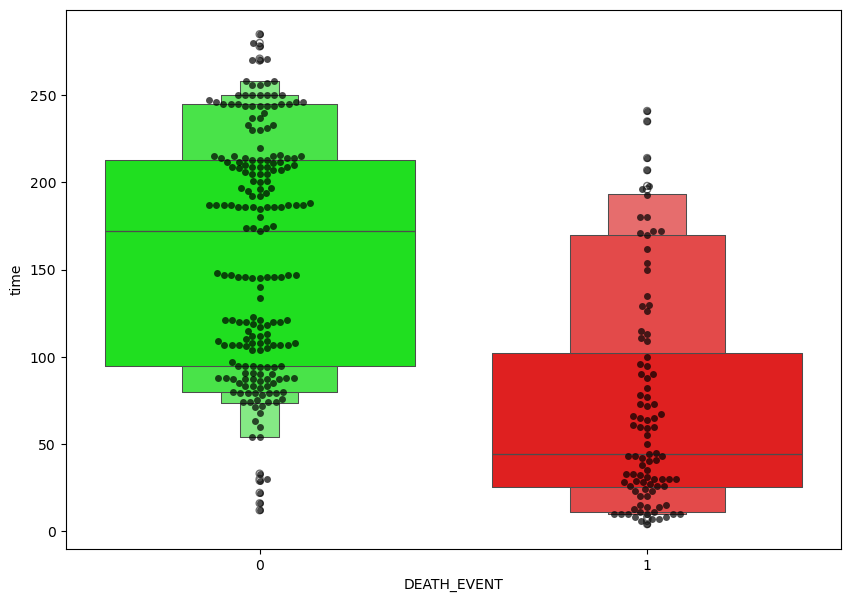

In [9]:
feature = ["age","creatinine_phosphokinase","ejection_fraction","platelets","serum_creatinine","serum_sodium","time"]
for i in feature:
    plt.figure(figsize=(10,7))
    sns.swarmplot(x=data_df["DEATH_EVENT"], y=data_df[i], color = "black", alpha = 0.7)
    sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)
    plt.show()

Data Preprocessing

In [10]:
X= data_df.drop(["DEATH_EVENT"], axis = 1)
y= data_df["DEATH_EVENT"]

In [11]:
col_name = list(X.columns)
s_scaler = preprocessing.StandardScaler()
X_scaled = s_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=col_name)

In [12]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


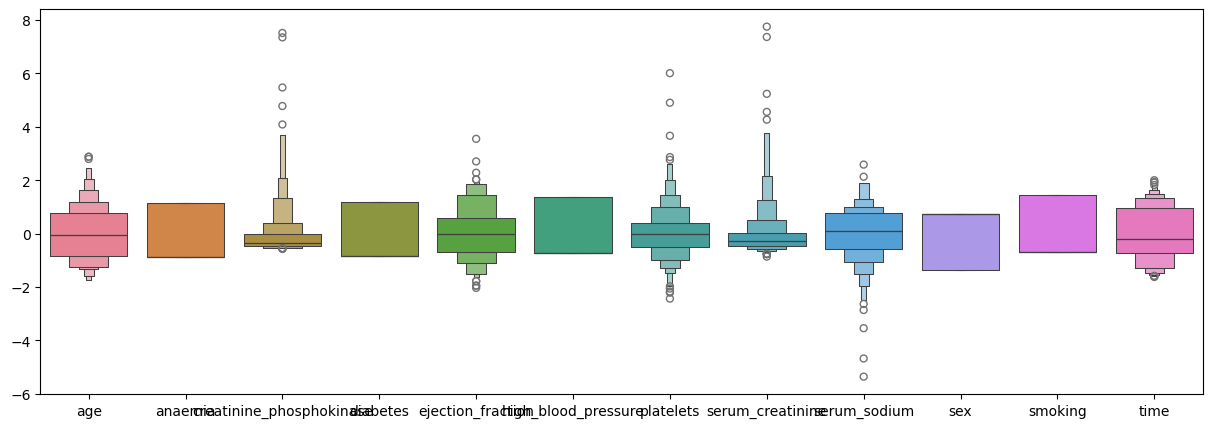

In [16]:
plt.figure(figsize=(15,5))
sns.boxenplot(data=X_scaled)
plt.show()

In [15]:
X_train,X_tests,y_train,y_test = train_test_split(X_scaled,y,test_size=0.3)

Model Building

1.SVM

In [16]:
model1 = svm.SVC()
model1.fit(X_train,y_train)

SVC()

In [17]:
y_pred = model1.predict(X_tests)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1])

In [18]:
y_test

60     1
292    0
241    0
108    0
207    0
      ..
193    0
132    0
103    0
159    0
5      1
Name: DEATH_EVENT, Length: 90, dtype: int64

In [19]:
y_train

82     1
165    1
129    0
206    0
222    0
      ..
211    0
276    0
77     0
13     1
281    0
Name: DEATH_EVENT, Length: 209, dtype: int64

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89        66
           1       0.76      0.54      0.63        24

    accuracy                           0.83        90
   macro avg       0.81      0.74      0.76        90
weighted avg       0.83      0.83      0.82        90




Confusion Matrix:


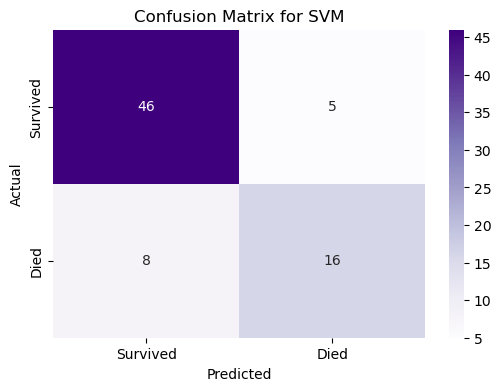


Overall Accuracy: 0.83


In [31]:
# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix for SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nOverall Accuracy: {accuracy_score(y_test, y_pred):.2f}")

2.ANN

In [21]:
early_stopping = callbacks.EarlyStopping(min_delta = 0.001, patience = 20, restore_best_weights = True)
model = Sequential()
model.add(Dense(units = 16,kernel_initializer = 'uniform', activation = 'relu', input_dim = 12))
model.add(Dense(units = 8,kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dropout(0.25))
model.add(Dense(units = 8,kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(units = 1,kernel_initializer = 'uniform', activation = 'sigmoid'))

C:\Users\appu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425 (1.66 KB)

 Trainable params: 425 (1.66 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(X_train,y_train,batch_size = 25,epochs = 100, callbacks=[early_stopping],validation_split=0.25)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.5256 - loss: 0.6931 - val_accuracy: 0.6226 - val_loss: 0.6927
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6667 - loss: 0.6921 - val_accuracy: 0.6226 - val_loss: 0.6919
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6667 - loss: 0.6910 - val_accuracy: 0.6226 - val_loss: 0.6910
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6667 - loss: 0.6898 - val_accuracy: 0.6226 - val_loss: 0.6903
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6667 - loss: 0.6889 - val_accuracy: 0.6226 - val_loss: 0.6896
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6667 - loss: 0.6877 - val_accuracy: 0.6226 - val_loss: 0.6887
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6667 - loss: 0.6866 - val_accuracy: 0.6226 - val_loss: 0.6877
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6667 - loss: 0.6848 - val_accuracy: 0.6226 - val_loss:

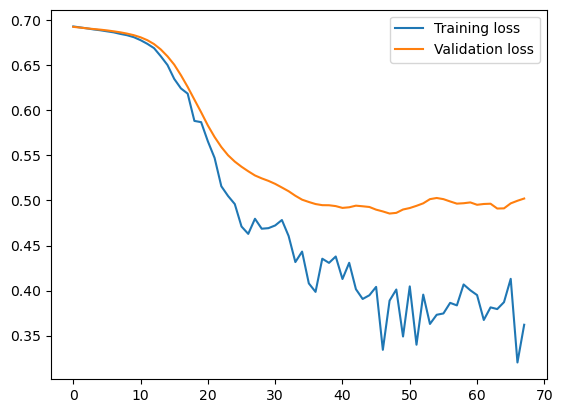

In [24]:
history_df = pd.DataFrame(history.history)
plt.plot(history_df.loc[:,['loss']],label = "Training loss")
plt.plot(history_df.loc[:,['val_loss']],label = "Validation loss")
plt.legend()
plt.show()

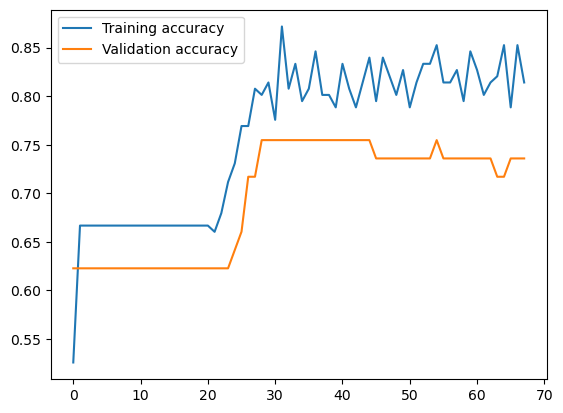

In [25]:
plt.plot(history_df.loc[:,['accuracy']],label = "Training accuracy")
plt.plot(history_df.loc[:,['val_accuracy']],label = "Validation accuracy")
plt.legend()
plt.show()

In [26]:
y_pred = model.predict(X_tests)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [27]:
y_pred = (y_pred > 0.5)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89        66
           1       0.71      0.62      0.67        24

    accuracy                           0.83        90
   macro avg       0.79      0.77      0.78        90
weighted avg       0.83      0.83      0.83        90



Heart Failure Prediction: Random Forest Model

Libraries Imported Successfully!
Dataset loaded successfully!

--- Training Random Forest Model ---
Model trained.

--- Evaluating Random Forest Model ---

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        51
           1       0.71      0.71      0.71        24

    accuracy                           0.81        75
   macro avg       0.79      0.79      0.79        75
weighted avg       0.81      0.81      0.81        75


Confusion Matrix:


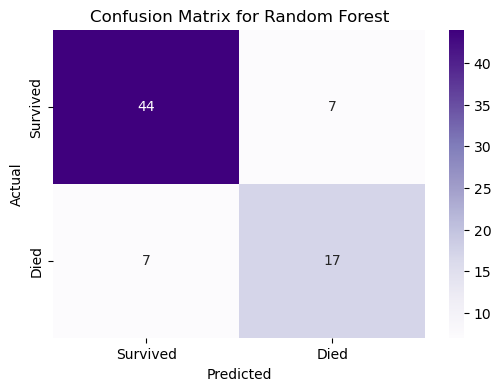


Overall Accuracy: 0.81


In [32]:
# 1. IMPORTING LIBRARIES
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Libraries Imported Successfully!")


# ==============================================================================
# 2. DATA LOADING & PREPARATION
# ==============================================================================
try:
    data_df = pd.read_csv("C:\\Users\\appu\\Downloads\\heart_failure_clinical_records_dataset.csv")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Dataset file not found. Please ensure 'heart_failure_clinical_records_dataset.csv' is in the same directory.")
    exit()

# --- Define Features (X) and Target (y) ---
X = data_df.drop("DEATH_EVENT", axis=1)
y = data_df["DEATH_EVENT"]

# --- Split Data into Training and Testing sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# --- Scale the data ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Handle Class Imbalance with SMOTE on Training Data ---
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)


# ==============================================================================
# 3. RANDOM FOREST MODEL TRAINING
# ==============================================================================
print("\n--- Training Random Forest Model ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
print("Model trained.")


# ==============================================================================
# 4. MODEL EVALUATION
# ==============================================================================
print("\n--- Evaluating Random Forest Model ---")
y_pred = rf_model.predict(X_test_scaled)

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix for Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nOverall Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Heart Failure Prediction: XGBoost Model

Libraries Imported Successfully!
Dataset loaded successfully!

--- Training XGBoost Model ---


C:\Users\appu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:10:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained.

--- Evaluating XGBoost Model ---

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88        51
           1       0.76      0.67      0.71        24

    accuracy                           0.83        75
   macro avg       0.81      0.78      0.79        75
weighted avg       0.82      0.83      0.82        75


Confusion Matrix:


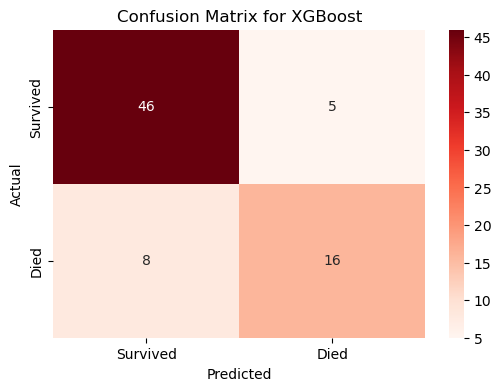


Overall Accuracy: 0.83


In [33]:
# 1. IMPORTING LIBRARIES
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Libraries Imported Successfully!")


# ==============================================================================
# 2. DATA LOADING & PREPARATION
# ==============================================================================
try:
    data_df = pd.read_csv("C:\\Users\\appu\\Downloads\\heart_failure_clinical_records_dataset.csv")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Dataset file not found. Please ensure 'heart_failure_clinical_records_dataset.csv' is in the same directory.")
    exit()

# --- Define Features (X) and Target (y) ---
X = data_df.drop("DEATH_EVENT", axis=1)
y = data_df["DEATH_EVENT"]

# --- Split Data into Training and Testing sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# --- Scale the data ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Handle Class Imbalance with SMOTE on Training Data ---
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)


# ==============================================================================
# 3. XGBOOST MODEL TRAINING
# ==============================================================================
print("\n--- Training XGBoost Model ---")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)
print("Model trained.")


# ==============================================================================
# 4. MODEL EVALUATION
# ==============================================================================
print("\n--- Evaluating XGBoost Model ---")
y_pred = xgb_model.predict(X_test_scaled)

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix for XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nOverall Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Agentic AI for Report Generation

In [ ]:

# 1. IMPORT LIBRARIES

import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import google.generativeai as genai
from IPython.display import Markdown


# 2. LOAD AND PREPARE DATA

# This section must run first to create X_test and y_test
data_df = pd.read_csv("C:\\Users\\appu\\Downloads\\heart_failure_clinical_records_dataset.csv")
X = data_df.drop("DEATH_EVENT", axis=1)
y = data_df["DEATH_EVENT"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)


# 3. TRAIN XGBOOST MODEL AND GET PREDICTIONS

#print("--- Training XGBoost Model ---")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)

# ---> THIS IS THE FIRST KEY LINE <---
# You must create the predictions from your model. This creates the 'y_pred_xgb' variable.
y_pred_xgb = xgb_model.predict(X_test_scaled)
#print("Model predictions generated.")


# 4. AGENTIC AI CODE (USING THE MODEL'S RESULTS)


# --- Configure the API ---
GOOGLE_API_KEY = '' # <--- PASTE API KEY HERE
genai.configure(api_key=GOOGLE_API_KEY)

# ---> THESE ARE THE NEXT KEY LINES <---
# These variables now store your model's specific performance metrics.
# They use 'y_test' and 'y_pred_xgb', which were created in the steps above.
xgb_report = classification_report(y_test, y_pred_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# ---> FINALLY, THIS IS THE LAST KEY PART <---
# The prompt now correctly uses the variables 'xgb_report' and 'cm_xgb'.
prompt = f"""
You are a medical data science analyst. Your task is to interpret the performance of a machine learning model that predicts mortality in heart failure patients and write a summary for a clinical audience (e.g., doctors) who may not be experts in data science metrics.

Here are the model's results:

**Classification Report:**
{xgb_report}

**Confusion Matrix:**
True Negatives (Predicted Survived, Actually Survived): {cm_xgb[0][0]}
False Positives (Predicted Died, Actually Survived): {cm_xgb[0][1]}
False Negatives (Predicted Survived, Actually Died): {cm_xgb[1][0]}
True Positives (Predicted Died, Actually Died): {cm_xgb[1][1]}

**Your Task:**
1.  Briefly explain the overall accuracy of the model.
2.  Crucially, explain what 'precision' and 'recall' mean for the "Died" class (class 1) in the context of this medical problem. Explain the clinical implications of false negatives vs. false positives.
3.  Provide a concluding thought on the model's potential usefulness and any areas for caution.
Keep the summary concise, clear, and focused on clinical relevance.
"""

# --- Call the Generative Model ---
#print("\n--- Generating AI Analysis ---")
model = genai.GenerativeModel('gemini-2.5-flash')
response = model.generate_content(prompt)

# --- Display the Agent's Report ---
print("\n--- Automated Report from AI Agent ---")
display(Markdown(response.text))

C:\Users\appu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:18:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Automated Report from AI Agent ---


**Model Performance Summary: Heart Failure Mortality Prediction**

This report summarizes the performance of a machine learning model designed to predict mortality in heart failure patients, specifically for a clinical audience.

1.  **Overall Accuracy:**
    The model demonstrates an overall accuracy of **83%**. This means that in 83 out of 100 cases, the model correctly predicted whether a patient would survive or die. This is a generally good starting point, indicating the model often makes the right call.

2.  **Focus on Predicting Mortality (Class 1: "Died"): Precision and Recall**

    When the model specifically predicts that a patient will **"die" (Class 1)**, two key metrics help us understand its reliability:

    *   **Precision (for "Died" class): 76%**
        *   **What it means:** When the model *predicts* a patient will die, it is correct 76% of the time. In other words, out of all patients the model flagged as high-risk for mortality, 76% actually succumbed.
        *   **Clinical Implication of errors (False Positives):** The remaining 24% (5 patients in this dataset) were **False Positives**. These are patients the model predicted would die, but they actually survived. Clinically, this could lead to unnecessary intensive monitoring, aggressive interventions, increased patient/family anxiety, or misallocation of scarce resources for patients who might not need such elevated care.

    *   **Recall (for "Died" class): 67%**
        *   **What it means:** The model correctly identified 67% of all patients who *actually* died. This means that out of all patients who truly died in this dataset, the model successfully flagged 67% of them.
        *   **Clinical Implication of errors (False Negatives):** The remaining 33% (8 patients in this dataset) were **False Negatives**. These are patients who actually died, but the model incorrectly predicted they would survive. This is a significant concern in mortality prediction, as it represents **missed opportunities** for timely and potentially life-saving interventions, closer monitoring, or initiating end-of-life discussions. From a patient safety perspective, false negatives are often considered more critical in this context.

3.  **Concluding Thoughts and Caution:**
    This model offers a promising tool for identifying heart failure patients at risk of mortality. Its ability to correctly predict death 76% of the time when it flags a patient, and to catch 67% of all actual deaths, suggests it could be valuable in triaging and resource allocation.

    However, the rate of **False Negatives (8 patients)**, where the model failed to predict death in patients who ultimately succumbed, is a critical area for caution. Relying solely on this model could lead to a false sense of security for some high-risk patients, potentially delaying crucial care. Therefore, while this model can serve as a supportive tool to augment clinical judgment and highlight potentially at-risk patients, it should **not replace comprehensive clinical assessment and expert decision-making**. Further refinement to reduce false negatives would significantly enhance its clinical utility.